# Insertion des variables 

In [2]:
import pickle
from pathlib import Path

data_dir = Path("Data")
data_dir.mkdir(exist_ok=True)
with open(data_dir / "ffor_data.pkl", "rb") as f_pkl:
    d = pickle.load(f_pkl)

# Remettre toutes les variables dans le namespace local
locals().update(d)

# Ou explicitement si tu préfères être précis :
n_nodes      = d["n_nodes"]
nodes        = d["nodes"]
pcc_bus      = d["pcc_bus"]
P_base       = d["P_base"]
Q_base       = d["Q_base"]
P_ref        = d["P_ref"]
Q_ref        = d["Q_ref"]
P_load       = d["P_load"]
Q_load       = d["Q_load"]
P_load_agg   = d["P_load_agg"]
Q_load_agg   = d["Q_load_agg"]
Pk_total     = d["Pk_total"]
line_data    = d["line_data"]
J_Ptheta     = d["J_Ptheta"]
J_QU         = d["J_QU"]
J_PU         = d["J_PU"]
J_Qtheta     = d["J_Qtheta"]
P_pv_max     = d["P_pv_max"]
Q_pv_max     = d["Q_pv_max"]
P_pv_max_dt  = d["P_pv_max_dt"]
Q_pv_max_dt  = d["Q_pv_max_dt"]
P_hp_max     = d["P_hp_max"]
P_hp_max_dt  = d["P_hp_max_dt"]
f_load_elec  = d["f_load_elec"]
f_load_chaleur = d["f_load_chaleur"]
alpha        = d["alpha"]
cos_phi      = d["cos_phi"]
V            = d["V"]
delta_Umin   = d["delta_Umin"]
delta_Umax   = d["delta_Umax"]

print("✅ Données chargées depuis ffor_data.pkl")

✅ Données chargées depuis ffor_data.pkl


# FFOR

Set parameter Username
Set parameter LicenseID to value 2806507
Academic license - for non-commercial use only - expires 2027-04-13
  1/72 | phi=0.0° | P=8.510, Q=3.748
  2/72 | phi=5.0° | P=8.510, Q=3.621
  3/72 | phi=10.0° | P=8.510, Q=3.621
  4/72 | phi=15.0° | P=8.510, Q=3.621
  5/72 | phi=20.0° | P=8.510, Q=3.621
  6/72 | phi=25.0° | P=8.510, Q=3.621
  7/72 | phi=30.0° | P=8.510, Q=3.621
  8/72 | phi=35.0° | P=8.510, Q=3.621
  9/72 | phi=40.0° | P=8.510, Q=3.621
  10/72 | phi=45.0° | P=8.510, Q=3.621
  11/72 | phi=50.0° | P=8.510, Q=3.621
  12/72 | phi=55.0° | P=8.510, Q=3.621
  13/72 | phi=60.0° | P=8.510, Q=3.621
  14/72 | phi=65.0° | P=8.510, Q=3.621
  15/72 | phi=70.0° | P=8.510, Q=3.621
  16/72 | phi=75.0° | P=8.510, Q=3.621
  17/72 | phi=80.0° | P=8.510, Q=3.621
  18/72 | phi=85.0° | P=8.510, Q=3.621
  19/72 | phi=90.0° | P=8.514, Q=3.621
  20/72 | phi=95.0° | P=8.933, Q=3.621
  21/72 | phi=100.0° | P=8.933, Q=3.621
  22/72 | phi=105.0° | P=8.933, Q=3.621
  23/72 | phi=110.0

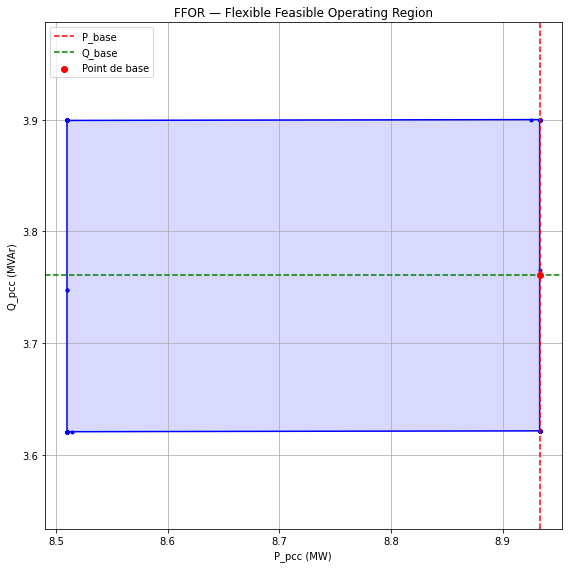

S_max min = 7.27 MVA
S_max max = 22.34 MVA
Plage P_pcc : [8.51, 8.93] MW
Plage Q_pcc : [3.62, 3.90] MVAr


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

def solve_ffor(a, b):
    """Résout le modèle FFOR pour une direction (a, b) donnée."""
    model = gp.Model("FFOR_static")
    model.Params.OutputFlag = 0  # silence Gurobi

    # --- Variables ---
    Pk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
    Qk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
    theta   = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
    P_pv    = model.addVars(n_nodes, lb=0,             name="Ppv")
    Q_pv    = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
    P_hp    = model.addVars(n_nodes, ub=0,             name="Php")

    # --- Contraintes ---
    for k in nodes:
        if k == pcc_bus:
            continue
        model.addConstr(Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0))
        model.addConstr(Qk[k] == Q_pv[k] + Q_load.get(k, 0))

    for k in nodes:
        model.addConstr(Pk[k] == P_ref[k] + gp.quicksum(J_Ptheta[k,j]*theta[j] + J_PU[k,j]*delta_U[j] for j in nodes))
        model.addConstr(Qk[k] == Q_ref[k] + gp.quicksum(J_Qtheta[k,j]*theta[j] + J_QU[k,j]*delta_U[j] for j in nodes))

    for k in nodes:
        model.addConstr(P_pv[k] <= P_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] <=  Q_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] >= -Q_pv_max.get(k, 0))
        model.addConstr(P_hp[k] >= P_hp_max.get(k, 0))

    for idx, row in line_data.iterrows():
        i, j = int(row["from_bus"]), int(row["to_bus"])
        Pij = - row["b"] * (theta[i] - theta[j])
        Qij = - row["b"] * (delta_U[i] - delta_U[j])
        model.addQConstr(Pij*Pij + Qij*Qij <= row["S_max"]**2)

    for k in nodes:
        model.addConstr(V + delta_U[k] >= delta_Umin * V)
        model.addConstr(V + delta_U[k] <= delta_Umax * V)

    model.addConstr(theta[pcc_bus] == 0)
    model.addConstr(delta_U[pcc_bus] == 0)

    # for k in nodes:
    #     S_inv = P_pv_max.get(k, 0) / cos_phi  # capacité apparente de l'onduleur
    #     model.addQConstr(
    #         P_pv[k] * P_pv[k] + Q_pv[k] * Q_pv[k] <= S_inv * S_inv,
    #         name=f"PV_Smax_{k}"
    #     )

    # --- Objectif directionnel ---
    model.setObjective(
        a * Pk[pcc_bus] + b * Qk[pcc_bus],
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus].X, Qk[pcc_bus].X
    else:
        return None, None


# --- Balayage sur 360° ---
n_angles = 72  # résolution : tous les 5°
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

P_points = []
Q_points = []

for i, phi in enumerate(angles):
    a = np.cos(phi)
    b = np.sin(phi)
    p, q = solve_ffor(a, b)
    if p is not None:
        P_points.append(p)
        Q_points.append(q)
    print(f"  {i+1}/{n_angles} | phi={np.degrees(phi):.1f}° | P={p:.3f}, Q={q:.3f}" if p else f"  {i+1}/{n_angles} | ❌ infaisable")

# Fermer le polygone
P_points.append(P_points[0])
Q_points.append(Q_points[0])

from pathlib import Path

# --- Plot ---
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 8))
plt.plot(P_points, Q_points, 'b-o', markersize=3, linewidth=1.5)
plt.fill(P_points, Q_points, alpha=0.15, color='blue')
plt.axvline(float(P_base[0]), color='r', linestyle='--', label='P_base')
plt.axhline(float(Q_base[0]), color='g', linestyle='--', label='Q_base')
plt.scatter([float(P_base[0])], [float(Q_base[0])], color='red', zorder=5, label='Point de base')
plt.xlabel("P_pcc (MW)")
plt.ylabel("Q_pcc (MVAr)")
plt.title("FFOR — Flexible Feasible Operating Region")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.savefig(output_dir / "FFOR.png", dpi=150)
plt.show()

print(f"S_max min = {line_data['S_max'].min():.2f} MVA")
print(f"S_max max = {line_data['S_max'].max():.2f} MVA")
print(f"Plage P_pcc : [{min(P_points):.2f}, {max(P_points):.2f}] MW")
print(f"Plage Q_pcc : [{min(Q_points):.2f}, {max(Q_points):.2f}] MVAr")

# Carte grille 87_0 avec BelalpSolar


In [1]:
import re
import math
from pathlib import Path

import pandas as pd
import pandapower as pp
import plotly.graph_objects as go
import plotly.io as pio
from plotly.colors import sample_colorscale

pio.renderers.default = "vscode"
# Après
data_dir = Path("Data")
grid_file = data_dir / "87_0_grid.xlsx"
grid_id = "87_0"
node_files = [data_dir / "nodes_valais.csv", Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_name = "BelalpSolar"
belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw = 5.7

net_map = pp.from_excel(grid_file)
pp.runpp(net_map)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_plot = net_map.bus.copy()
bus_plot["bus"] = bus_plot.index.astype(int)
bus_plot["node_id"] = bus_plot["name"].apply(node_id_from_bus_name)
bus_plot = bus_plot.join(node_lookup, on="node_id")
bus_plot = bus_plot.dropna(subset=["longitude", "latitude"]).set_index("bus")

if bus_plot.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

distance2 = (bus_plot["longitude"] - belalp_longitude) ** 2 + (bus_plot["latitude"] - belalp_latitude) ** 2
nearest_bus = int(distance2.idxmin())
nearest_lon = float(bus_plot.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_plot.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

load_by_bus = net_map.load[net_map.load["in_service"]].groupby("bus")["p_mw"].sum() if len(net_map.load) else pd.Series(dtype=float)
sgen_by_bus = net_map.sgen[net_map.sgen["in_service"]].groupby("bus")["p_mw"].sum() if len(net_map.sgen) else pd.Series(dtype=float)
slack_buses = set(net_map.ext_grid[net_map.ext_grid["in_service"]]["bus"].astype(int))
max_load = max(float(load_by_bus.max()), 1e-9) if len(load_by_bus) else 1.0
max_sgen = max(float(sgen_by_bus.max()), 1e-9) if len(sgen_by_bus) else 1.0
max_loading = max(float(net_map.res_line["loading_percent"].max()), 1.0)

fig = go.Figure()

for line_idx, line in net_map.line.iterrows():
    from_bus = int(line["from_bus"])
    to_bus = int(line["to_bus"])
    if from_bus not in bus_plot.index or to_bus not in bus_plot.index:
        continue
    x0, y0 = bus_plot.loc[from_bus, ["longitude", "latitude"]]
    x1, y1 = bus_plot.loc[to_bus, ["longitude", "latitude"]]
    loading = float(net_map.res_line.loc[line_idx, "loading_percent"])
    fig.add_trace(go.Scatter(
        x=[x0, x1],
        y=[y0, y1],
        mode="lines",
        line=dict(color=sample_colorscale("Viridis", loading / max_loading)[0], width=2.2),
        hovertemplate=f"line {line_idx}<br>loading: {loading:.2f}%<extra></extra>",
        showlegend=False,
    ))

# Ligne visuelle du raccordement BelalpSolar -> bus le plus proche.
fig.add_trace(go.Scatter(
    x=[nearest_lon, belalp_longitude],
    y=[nearest_lat, belalp_latitude],
    mode="lines",
    line=dict(color="limegreen", width=4, dash="dash"),
    name=f"Raccordement {belalp_name}",
    hovertemplate=(
        f"{belalp_name} -> bus {nearest_bus}"
        f"<br>longueur approx.: {connection_length_km:.2f} km<extra></extra>"
    ),
))

plain, loads, slacks, sgens = [], [], [], []
for bus_idx, row in bus_plot.iterrows():
    load = float(load_by_bus.get(bus_idx, 0.0))
    sgen = float(sgen_by_bus.get(bus_idx, 0.0))
    item = dict(bus=int(bus_idx), lon=float(row["longitude"]), lat=float(row["latitude"]), load=load, sgen=sgen)
    if bus_idx in slack_buses:
        slacks.append(item)
    elif load > 0:
        loads.append(item)
    elif sgen > 0:
        sgens.append(item)
    else:
        plain.append(item)


def add_nodes(items, name, color, symbol, size_fn, line_color="white", line_width=1):
    if not items:
        return
    fig.add_trace(go.Scatter(
        x=[item["lon"] for item in items],
        y=[item["lat"] for item in items],
        mode="markers+text",
        text=[str(item["bus"]) for item in items],
        textposition="top center",
        textfont=dict(size=9),
        marker=dict(symbol=symbol, size=[size_fn(item) for item in items], color=color, line=dict(color=line_color, width=line_width)),
        customdata=[[item["bus"], item["load"], item["sgen"]] for item in items],
        hovertemplate="bus %{customdata[0]}<br>load: %{customdata[1]:.4f} MW<br>sgen: %{customdata[2]:.4f} MW<extra></extra>",
        name=name,
    ))


add_nodes(plain, "Bus", "lightgray", "circle", lambda item: 7, line_color="dimgray")
add_nodes(loads, "Load", "red", "circle", lambda item: 7 + 22 * item["load"] / max_load)
add_nodes(sgens, "Generator", "royalblue", "diamond", lambda item: 9 + 18 * item["sgen"] / max_sgen)
add_nodes(slacks, "Slack / ext_grid", "gold", "star", lambda item: 24, line_color="black", line_width=2)

fig.add_trace(go.Scatter(
    x=[belalp_longitude],
    y=[belalp_latitude],
    mode="markers+text",
    text=[belalp_name],
    textposition="bottom right",
    marker=dict(symbol="diamond", size=22, color="limegreen", line=dict(color="darkgreen", width=2)),
    customdata=[[belalp_p_mw, nearest_bus, connection_length_km]],
    hovertemplate=(
        f"{belalp_name}<br>PV nominal: %{{customdata[0]:.2f}} MW"
        "<br>bus raccordement: %{customdata[1]}"
        "<br>distance approx.: %{customdata[2]:.2f} km<extra></extra>"
    ),
    name=belalp_name,
))

fig.update_layout(
    title=f"Grille {grid_id} avec point {belalp_name} - bus le plus proche: {nearest_bus}",
    width=1150,
    height=850,
    dragmode="zoom",
    hovermode="closest",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    legend=dict(title="Elements", x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.88)", bordercolor="rgba(0,0,0,0.25)", borderwidth=1),
    margin=dict(l=50, r=40, t=70, b=50),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

print(f"BelalpSolar: latitude={belalp_latitude}, longitude={belalp_longitude}, P_nom={belalp_p_mw} MW")
print(f"Bus de raccordement le plus proche: {nearest_bus}, distance approx. {connection_length_km:.2f} km")


KeyError: 'parameter'

# FFOR avec BelalpSolar dans le réseau pandapower


In [5]:
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import pandapower as pp
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# Cette cellule reconstruit le reseau pandapower, ajoute BelalpSolar, puis recalcule
# le FFOR avec les memes conventions que les cellules FFOR precedentes.
# Après
data_dir = Path("Data")
grid_file = data_dir / "87_0_grid.xlsx"
grid_id = "87_0"
node_files = [data_dir / "nodes_valais.csv", Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw_nominal = 5.7
belalp_q_mvar = 0.0
belalp_name = "BelalpSolar PV"


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


belalp_net = pp.from_excel(grid_file)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")
nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_geo = belalp_net.bus.copy()
bus_geo["bus"] = bus_geo.index.astype(int)
bus_geo["node_id"] = bus_geo["name"].apply(node_id_from_bus_name)
bus_geo = bus_geo.join(node_lookup, on="node_id").dropna(subset=["longitude", "latitude"]).set_index("bus")

if bus_geo.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

nearest_bus = int(((bus_geo["longitude"] - belalp_longitude) ** 2 + (bus_geo["latitude"] - belalp_latitude) ** 2).idxmin())
nearest_lon = float(bus_geo.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_geo.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

attached_lines = belalp_net.line[(belalp_net.line["from_bus"] == nearest_bus) | (belalp_net.line["to_bus"] == nearest_bus)]
cable = attached_lines.iloc[0] if len(attached_lines) else belalp_net.line.iloc[0]

belalp_bus = pp.create_bus(
    belalp_net,
    vn_kv=float(belalp_net.bus.loc[nearest_bus, "vn_kv"]),
    name="bus_MV_87_0_BelalpSolar",
    type="n",
)
pp.create_line_from_parameters(
    belalp_net,
    from_bus=nearest_bus,
    to_bus=belalp_bus,
    length_km=max(connection_length_km, 1e-4),
    r_ohm_per_km=float(cable["r_ohm_per_km"]),
    x_ohm_per_km=float(cable["x_ohm_per_km"]),
    c_nf_per_km=float(cable["c_nf_per_km"]),
    max_i_ka=float(cable["max_i_ka"]),
    type=str(cable.get("type", "ol")),
    name="line_87_0_to_BelalpSolar",
)
pp.create_sgen(
    belalp_net,
    bus=belalp_bus,
    p_mw=belalp_p_mw_nominal,
    q_mvar=belalp_q_mvar,
    name=belalp_name,
    type="PV",
)
pp.runpp(belalp_net, calculate_voltage_angles=True)

buses_belalp = list(map(int, belalp_net.bus.index))
n_nodes_belalp = len(buses_belalp)
bus_position = {bus: i for i, bus in enumerate(buses_belalp)}
pcc_bus_belalp = int(belalp_net.ext_grid.loc[belalp_net.ext_grid["in_service"], "bus"].iloc[0])

line_data_belalp = belalp_net.line[belalp_net.line["in_service"]].copy()
line_data_belalp["r"] = line_data_belalp["r_ohm_per_km"] * line_data_belalp["length_km"]
line_data_belalp["x"] = line_data_belalp["x_ohm_per_km"] * line_data_belalp["length_km"]
line_data_belalp["g"] = line_data_belalp["r"] / (line_data_belalp["r"] ** 2 + line_data_belalp["x"] ** 2)
line_data_belalp["b"] = -line_data_belalp["x"] / (line_data_belalp["r"] ** 2 + line_data_belalp["x"] ** 2)
line_data_belalp["S_max"] = np.sqrt(3) * line_data_belalp["max_i_ka"] * line_data_belalp["from_bus"].map(belalp_net.bus["vn_kv"])

J_Ptheta_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
J_QU_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
J_PU_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
for _, line in line_data_belalp.iterrows():
    i = bus_position[int(line["from_bus"])]
    j = bus_position[int(line["to_bus"])]
    gij = float(line["g"])
    bij = float(line["b"])
    J_Ptheta_b[i, i] -= bij
    J_Ptheta_b[j, j] -= bij
    J_Ptheta_b[i, j] += bij
    J_Ptheta_b[j, i] += bij
    J_QU_b[i, i] -= bij
    J_QU_b[j, j] -= bij
    J_QU_b[i, j] += bij
    J_QU_b[j, i] += bij
    J_PU_b[i, i] += gij
    J_PU_b[j, j] += gij
    J_PU_b[i, j] -= gij
    J_PU_b[j, i] -= gij
J_Qtheta_b = -J_PU_b

P_ref_b = -belalp_net.res_bus.reindex(buses_belalp)["p_mw"].fillna(0).values
Q_ref_b = -belalp_net.res_bus.reindex(buses_belalp)["q_mvar"].fillna(0).values
P_base_b = float(belalp_net.res_ext_grid["p_mw"].iloc[0])
Q_base_b = float(belalp_net.res_ext_grid["q_mvar"].iloc[0])

load_p_b = -belalp_net.load[belalp_net.load["in_service"]].groupby("bus")["p_mw"].sum().reindex(buses_belalp, fill_value=0.0)
load_q_b = -belalp_net.load[belalp_net.load["in_service"]].groupby("bus")["q_mvar"].sum().reindex(buses_belalp, fill_value=0.0)

pv_pmax_b = pd.Series(0.0, index=buses_belalp)
pv_qmax_b = pd.Series(0.0, index=buses_belalp)
if "P_pv_max" in globals():
    for bus, value in P_pv_max.items():
        if int(bus) in pv_pmax_b.index:
            pv_pmax_b.loc[int(bus)] = float(value)
if "Q_pv_max" in globals():
    for bus, value in Q_pv_max.items():
        if int(bus) in pv_qmax_b.index:
            pv_qmax_b.loc[int(bus)] = abs(float(value))
pv_pmax_b.loc[int(belalp_bus)] = belalp_p_mw_nominal
pv_qmax_b.loc[int(belalp_bus)] = belalp_p_mw_nominal * np.tan(np.arccos(cos_phi if "cos_phi" in globals() else 0.95))

hp_pmax_b = pd.Series(0.0, index=buses_belalp)
if "P_hp_max" in globals():
    for bus, value in P_hp_max.items():
        if int(bus) in hp_pmax_b.index:
            hp_pmax_b.loc[int(bus)] = float(value)

u_min = float(delta_Umin * V if "delta_Umin" in globals() and "V" in globals() else 18.0)
u_max = float(delta_Umax * V if "delta_Umax" in globals() and "V" in globals() else 22.0)
voltage_kv = float(V if "V" in globals() else belalp_net.bus.loc[pcc_bus_belalp, "vn_kv"])
cos_phi_local = float(cos_phi if "cos_phi" in globals() else 0.95)


def solve_ffor_belalp_direction(a, b):
    model = gp.Model("FFOR_belalp_pandapower")
    model.Params.OutputFlag = 0

    Pk = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Pk")
    Qk = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Qk")
    theta = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="U")
    P_pv = model.addVars(buses_belalp, lb=0.0, name="Ppv")
    Q_pv = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Qpv")
    P_hp = model.addVars(buses_belalp, ub=0.0, name="Php")

    for bus in buses_belalp:
        if bus != pcc_bus_belalp:
            model.addConstr(Pk[bus] == P_pv[bus] + P_hp[bus] + float(load_p_b.loc[bus]))
            model.addConstr(Qk[bus] == Q_pv[bus] + float(load_q_b.loc[bus]))

        i = bus_position[bus]
        model.addConstr(Pk[bus] == P_ref_b[i] + gp.quicksum(J_Ptheta_b[i, j] * theta[buses_belalp[j]] + J_PU_b[i, j] * delta_U[buses_belalp[j]] for j in range(n_nodes_belalp)))
        model.addConstr(Qk[bus] == Q_ref_b[i] + gp.quicksum(J_Qtheta_b[i, j] * theta[buses_belalp[j]] + J_QU_b[i, j] * delta_U[buses_belalp[j]] for j in range(n_nodes_belalp)))

        model.addConstr(P_pv[bus] <= float(pv_pmax_b.loc[bus]))
        model.addConstr(Q_pv[bus] <= float(pv_qmax_b.loc[bus]))
        model.addConstr(Q_pv[bus] >= -float(pv_qmax_b.loc[bus]))
        model.addConstr(P_hp[bus] >= float(hp_pmax_b.loc[bus]))
        model.addConstr(voltage_kv + delta_U[bus] >= u_min)
        model.addConstr(voltage_kv + delta_U[bus] <= u_max)

        s_inv = float(pv_pmax_b.loc[bus]) / max(cos_phi_local, 1e-9)
        if s_inv > 0:
            model.addQConstr(P_pv[bus] * P_pv[bus] + Q_pv[bus] * Q_pv[bus] <= s_inv * s_inv)
        else:
            model.addConstr(P_pv[bus] == 0.0)
            model.addConstr(Q_pv[bus] == 0.0)

    for _, line in line_data_belalp.iterrows():
        from_bus = int(line["from_bus"])
        to_bus = int(line["to_bus"])
        bij = float(line["b"])
        smax = float(line["S_max"])
        Pij = -bij * (theta[from_bus] - theta[to_bus])
        Qij = -bij * (delta_U[from_bus] - delta_U[to_bus])
        model.addQConstr(Pij * Pij + Qij * Qij <= smax * smax)

    model.addConstr(theta[pcc_bus_belalp] == 0.0)
    model.addConstr(delta_U[pcc_bus_belalp] == 0.0)
    model.setObjective(a * Pk[pcc_bus_belalp] + b * Qk[pcc_bus_belalp], GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus_belalp].X, Qk[pcc_bus_belalp].X
    return None, None


n_angles_belalp = 72
angles_belalp = np.linspace(0, 2 * np.pi, n_angles_belalp, endpoint=False)
P_points_belalp = []
Q_points_belalp = []

for idx, phi in enumerate(angles_belalp):
    p_val, q_val = solve_ffor_belalp_direction(np.cos(phi), np.sin(phi))
    if p_val is not None:
        P_points_belalp.append(p_val)
        Q_points_belalp.append(q_val)
    print(f"{idx + 1}/{n_angles_belalp} | phi={np.degrees(phi):.1f} deg | P={p_val}, Q={q_val}")

if len(P_points_belalp) < 3:
    raise RuntimeError("Pas assez de points optimaux pour tracer le FFOR avec BelalpSolar.")

P_closed_belalp = P_points_belalp + [P_points_belalp[0]]
Q_closed_belalp = Q_points_belalp + [Q_points_belalp[0]]

plt.figure(figsize=(8, 8))
plt.plot(P_closed_belalp, Q_closed_belalp, "b-o", markersize=3, linewidth=1.5, label="FFOR avec BelalpSolar")
plt.fill(P_closed_belalp, Q_closed_belalp, alpha=0.15, color="blue")
plt.axvline(P_base_b, color="r", linestyle="--", label="P_base pandapower")
plt.axhline(Q_base_b, color="g", linestyle="--", label="Q_base pandapower")
plt.scatter([P_base_b], [Q_base_b], color="red", zorder=5, label="Point de base")
plt.xlabel("P_pcc (MW)")
plt.ylabel("Q_pcc (MVAr)")
plt.title("FFOR avec BelalpSolar raccorde dans pandapower")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.savefig("FFOR_belalp.png", dpi=150)
plt.show()

print(f"BelalpSolar ajoute au bus pandapower {belalp_bus}, raccorde au bus {nearest_bus}")
print(f"Longueur ligne Belalp approx.: {connection_length_km:.2f} km")
print(f"Point de base pandapower avec Belalp: P={P_base_b:.3f} MW, Q={Q_base_b:.3f} MVAr")
print(f"Plage P_pcc avec Belalp: [{min(P_points_belalp):.2f}, {max(P_points_belalp):.2f}] MW")
print(f"Plage Q_pcc avec Belalp: [{min(Q_points_belalp):.2f}, {max(Q_points_belalp):.2f}] MVAr")


KeyError: 'parameter'

# Carte power flow avec BelalpSolar raccorde par ligne OHL


In [22]:
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import pandapower as pp
import plotly.graph_objects as go
import plotly.io as pio
from plotly.colors import sample_colorscale

pio.renderers.default = "vscode"

# Objectif: ajouter physiquement BelalpSolar dans pandapower avec une ligne OHL,
# lancer un power flow, puis cartographier la charge de chaque ligne.
grid_file = Path("87_0_grid.xlsx")
grid_id = "87_0"
node_files = [Path("nodes_valais.csv"), Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_name = "BelalpSolar PV"
belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw = 5.7
belalp_q_mvar = 0.0


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


pf_net = pp.from_excel(grid_file)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")
nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_plot = pf_net.bus.copy()
bus_plot["bus"] = bus_plot.index.astype(int)
bus_plot["node_id"] = bus_plot["name"].apply(node_id_from_bus_name)
bus_plot = bus_plot.join(node_lookup, on="node_id").dropna(subset=["longitude", "latitude"]).set_index("bus")
if bus_plot.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

# Bus de raccordement: bus existant le plus proche de la position BelalpSolar.
distance2 = (bus_plot["longitude"] - belalp_longitude) ** 2 + (bus_plot["latitude"] - belalp_latitude) ** 2
nearest_bus = int(distance2.idxmin())
nearest_lon = float(bus_plot.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_plot.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

# Parametres de la ligne OHL: on prend une ligne aerienne existante du reseau si disponible.
line_type = pf_net.line.get("type", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
std_type = pf_net.line.get("std_type", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
name_type = pf_net.line.get("name", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
ohl_mask = line_type.eq("ol") | std_type.str.contains("ohl|al1|st1|overhead", regex=True) | name_type.str.contains("ohl|al1|st1|overhead", regex=True)
ohl_candidates = pf_net.line[ohl_mask]
if len(ohl_candidates):
    ohl_line_template = ohl_candidates.iloc[0]
else:
    print("Aucune ligne OHL existante detectee; utilisation de parametres OHL de secours.")
    ohl_line_template = pd.Series({
        "r_ohm_per_km": 0.5939,
        "x_ohm_per_km": 0.372,
        "c_nf_per_km": 9.5,
        "max_i_ka": 0.12,
        "type": "ol",
    })

# 1) Creer le bus BelalpSolar.
belalp_bus = pp.create_bus(
    pf_net,
    vn_kv=float(pf_net.bus.loc[nearest_bus, "vn_kv"]),
    name="bus_MV_87_0_BelalpSolar",
    type="n",
)

# 2) Creer la source PV sur ce bus.
belalp_sgen = pp.create_sgen(
    pf_net,
    bus=belalp_bus,
    p_mw=belalp_p_mw,
    q_mvar=belalp_q_mvar,
    name=belalp_name,
    type="PV",
)

# 3) Raccorder physiquement BelalpSolar au reseau avec une ligne OHL pandapower.
belalp_line = pp.create_line_from_parameters(
    pf_net,
    from_bus=nearest_bus,
    to_bus=belalp_bus,
    length_km=max(connection_length_km, 1e-4),
    r_ohm_per_km=float(ohl_line_template["r_ohm_per_km"]),
    x_ohm_per_km=float(ohl_line_template["x_ohm_per_km"]),
    c_nf_per_km=float(ohl_line_template["c_nf_per_km"]),
    max_i_ka=float(ohl_line_template["max_i_ka"]),
    type="ol",
    name="OHL_87_0_to_BelalpSolar",
)

# 4) Power flow avec la source et la ligne OHL dans pandapower.
pp.runpp(pf_net, calculate_voltage_angles=True)

# Ajouter les coordonnees du nouveau bus pour la carte.
bus_plot = pd.concat([
    bus_plot,
    pd.DataFrame(
        {"longitude": [belalp_longitude], "latitude": [belalp_latitude], "name": ["bus_MV_87_0_BelalpSolar"], "node_id": ["BelalpSolar"]},
        index=[belalp_bus],
    ),
])

line_loading = pf_net.res_line["loading_percent"].astype(float)
max_loading = max(float(line_loading.max()), 1.0)
fig = go.Figure()

for line_idx, line in pf_net.line.iterrows():
    from_bus = int(line["from_bus"])
    to_bus = int(line["to_bus"])
    if from_bus not in bus_plot.index or to_bus not in bus_plot.index:
        continue

    x0, y0 = bus_plot.loc[from_bus, ["longitude", "latitude"]]
    x1, y1 = bus_plot.loc[to_bus, ["longitude", "latitude"]]
    x_mid = (x0 + x1) / 2
    y_mid = (y0 + y1) / 2
    loading = float(pf_net.res_line.loc[line_idx, "loading_percent"])
    p_from = float(pf_net.res_line.loc[line_idx, "p_from_mw"])
    q_from = float(pf_net.res_line.loc[line_idx, "q_from_mvar"])
    is_belalp_line = int(line_idx) == int(belalp_line)
    color = "limegreen" if is_belalp_line else sample_colorscale("Turbo", min(loading / max_loading, 1.0))[0]
    width = 5.5 if is_belalp_line else 1.5 + 5.0 * loading / max_loading

    fig.add_trace(go.Scatter(
        x=[x0, x_mid, x1],
        y=[y0, y_mid, y1],
        mode="lines+text",
        text=[None, f"{loading:.1f}%", None],
        textposition="middle center",
        textfont=dict(size=9, color="black"),
        line=dict(color=color, width=width, dash="dash" if is_belalp_line else "solid"),
        customdata=[[line_idx, from_bus, to_bus, loading, p_from, q_from]] * 3,
        hovertemplate=(
            "line %{customdata[0]}<br>"
            "%{customdata[1]} -> %{customdata[2]}<br>"
            "loading: %{customdata[3]:.2f}%<br>"
            "P_from: %{customdata[4]:.3f} MW<br>"
            "Q_from: %{customdata[5]:.3f} MVAr<extra></extra>"
        ),
        showlegend=False,
    ))

# Colorbar invisible pour l'echelle loading.
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode="markers",
    marker=dict(
        colorscale="Turbo",
        cmin=0,
        cmax=max_loading,
        color=[0],
        colorbar=dict(title="Loading line (%)", x=1.02, y=0.5, len=0.75, thickness=18),
        showscale=True,
    ),
    hoverinfo="skip",
    showlegend=False,
))

load_by_bus = pf_net.load[pf_net.load["in_service"]].groupby("bus")["p_mw"].sum() if len(pf_net.load) else pd.Series(dtype=float)
sgen_by_bus = pf_net.sgen[pf_net.sgen["in_service"]].groupby("bus")["p_mw"].sum() if len(pf_net.sgen) else pd.Series(dtype=float)
slack_buses = set(pf_net.ext_grid[pf_net.ext_grid["in_service"]]["bus"].astype(int))
max_load = max(float(load_by_bus.max()), 1e-9) if len(load_by_bus) else 1.0

plain, loads, slacks, pvs = [], [], [], []
for bus_idx, row in bus_plot.iterrows():
    load = float(load_by_bus.get(bus_idx, 0.0))
    sgen = float(sgen_by_bus.get(bus_idx, 0.0))
    item = dict(bus=int(bus_idx), lon=float(row["longitude"]), lat=float(row["latitude"]), load=load, sgen=sgen)
    if int(bus_idx) == int(belalp_bus):
        pvs.append(item)
    elif bus_idx in slack_buses:
        slacks.append(item)
    elif load > 0:
        loads.append(item)
    else:
        plain.append(item)


def add_nodes(items, name, color, symbol, size_fn, line_color="white", line_width=1):
    if not items:
        return
    fig.add_trace(go.Scatter(
        x=[item["lon"] for item in items],
        y=[item["lat"] for item in items],
        mode="markers+text",
        text=["BelalpSolar" if item["bus"] == belalp_bus else str(item["bus"]) for item in items],
        textposition="top center",
        textfont=dict(size=9),
        marker=dict(symbol=symbol, size=[size_fn(item) for item in items], color=color, line=dict(color=line_color, width=line_width)),
        customdata=[[item["bus"], item["load"], item["sgen"]] for item in items],
        hovertemplate="bus %{customdata[0]}<br>load: %{customdata[1]:.4f} MW<br>sgen: %{customdata[2]:.4f} MW<extra></extra>",
        name=name,
    ))


add_nodes(plain, "Bus", "lightgray", "circle", lambda item: 6, line_color="dimgray")
add_nodes(loads, "Load", "red", "circle", lambda item: 6 + 20 * item["load"] / max_load)
add_nodes(slacks, "Slack / ext_grid", "gold", "star", lambda item: 24, line_color="black", line_width=2)
add_nodes(pvs, belalp_name, "limegreen", "diamond", lambda item: 24, line_color="darkgreen", line_width=2)

fig.update_layout(
    title=f"Power flow pandapower avec {belalp_name} raccorde en OHL | max loading {max_loading:.2f}%",
    width=1250,
    height=900,
    dragmode="zoom",
    hovermode="closest",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    legend=dict(title="Elements", x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.88)", bordercolor="rgba(0,0,0,0.25)", borderwidth=1),
    margin=dict(l=50, r=150, t=75, b=50),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

line_loading_summary = pf_net.line[["name", "from_bus", "to_bus", "length_km", "max_i_ka", "type"]].copy()
line_loading_summary["loading_percent"] = pf_net.res_line["loading_percent"]
line_loading_summary["p_from_mw"] = pf_net.res_line["p_from_mw"]
line_loading_summary["q_from_mvar"] = pf_net.res_line["q_from_mvar"]
line_loading_summary["is_belalp_ohl"] = line_loading_summary.index == belalp_line
line_loading_summary = line_loading_summary.sort_values("loading_percent", ascending=False)

display(line_loading_summary)
print(f"Power flow converge: {pf_net.converged}")
print(f"BelalpSolar source sgen index: {belalp_sgen}, bus: {belalp_bus}, P={belalp_p_mw:.2f} MW, Q={belalp_q_mvar:.2f} MVAr")
print(f"Raccordement OHL: ligne {belalp_line}, bus {nearest_bus} -> {belalp_bus}, longueur {connection_length_km:.2f} km")
print(f"Max loading: {line_loading_summary['loading_percent'].iloc[0]:.2f}% sur ligne {line_loading_summary.index[0]}")


,name,from_bus,to_bus,length_km,max_i_ka,type,loading_percent,p_from_mw,q_from_mvar,is_belalp_ohl
75,OHL_87_0_to_BelalpSolar,42,77,2.302822,0.210,ol,76.825761,-5.593206,0.064086,True
45,MV_87_0_line_45,38,42,0.127498,0.220,cs,70.646822,-5.382027,0.162545,False
26,MV_87_0_line_26,23,24,0.034044,0.220,cs,31.915720,-2.217318,-0.987833,False
16,MV_87_0_line_16,14,28,0.087212,0.220,cs,26.820146,-1.848484,-0.845673,False
30,MV_87_0_line_30,25,28,1.333740,0.220,cs,26.808852,1.855043,0.813951,False
27,MV_87_0_line_27,23,25,0.063939,0.220,cs,26.638795,1.855336,0.812518,False
10,MV_87_0_line_10,6,14,0.058771,0.210,ol,21.624411,-1.426411,-0.641932,False
24,MV_87_0_line_24,20,22,0.030173,0.638,cs,21.060013,2.893564,3.639203,False
22,MV_87_0_line_22,18,20,0.297059,0.638,cs,21.053304,2.895214,3.621490,False
21,MV_87_0_line_21,18,19,0.316453,0.638,cs,20.987309,-2.895214,-3.621490,False


Power flow converge: True
BelalpSolar source sgen index: 0, bus: 77, P=5.70 MW, Q=0.00 MVAr
Raccordement OHL: ligne 75, bus 42 -> 77, longueur 2.30 km
Max loading: 76.83% sur ligne 75
